In [26]:
!pip install gradio kagglehub plotly scikit-learn -q

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
import gradio as gr
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings
import kagglehub
from sklearn.feature_extraction.text import TfidfVectorizer


In [28]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

In [38]:
path = kagglehub.dataset_download("prasertk/mobile-phone-rating")

df = os.listdir(path)
csv_file = [f for f in df if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))



In [39]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   model    223 non-null    object 
 1   price    223 non-null    object 
 2   launch   223 non-null    object 
 3   camera   184 non-null    float64
 4   selfie   72 non-null     float64
 5   audio    93 non-null     float64
 6   display  64 non-null     float64
 7   battery  54 non-null     float64
dtypes: float64(5), object(3)
memory usage: 14.1+ KB


,0
model,0
price,0
launch,0
camera,39
selfie,151
audio,130
display,159
battery,169


In [40]:
# data cleaning
df_clean = df.copy()

# duplikasi data
init_row = len(df_clean)
print('Jumlah baris awal:', init_row)
df_clean = df_clean.drop_duplicates(subset=['model'])

Jumlah baris awal: 223


In [41]:

# missvalue
df_clean = df_clean.dropna(subset=['model'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   model    223 non-null    object 
 1   price    223 non-null    object 
 2   launch   223 non-null    object 
 3   camera   184 non-null    float64
 4   selfie   72 non-null     float64
 5   audio    93 non-null     float64
 6   display  64 non-null     float64
 7   battery  54 non-null     float64
dtypes: float64(5), object(3)
memory usage: 14.1+ KB


In [42]:
# hapus kolom price karena kita gak pake itu
df_clean.drop('price', axis=1, inplace=True)
# tampilkan data
df_clean.head()

,model,launch,camera,selfie,audio,display,battery
0,Huawei P50 Pro,Jul 2021,144.0,106.0,NaN,93.0,NaN
1,Xiaomi Mi 11 Ultra,Mar 2021,143.0,94.0,71.0,87.0,69.0
2,Huawei Mate 40 Pro+,Oct 2020,139.0,NaN,NaN,NaN,NaN
3,Apple iPhone 13 Pro Max,Sep 2021,137.0,99.0,75.0,99.0,89.0
4,Apple iPhone 13 Pro,Sep 2021,137.0,99.0,75.0,98.0,76.0


In [43]:
# ngisi miss value dengan median

num_cols = ['camera', 'selfie', 'audio', 'display', 'battery']

for col in num_cols:
    if col in df_clean.columns:
        before = df_clean[col].isnull().sum()
        df_clean[col] = pd.to_numeric(df_clean[col], errors = 'coerce')
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        after = df_clean[col].isnull().sum()
        if before>0:
            print(f" {col} : terisi {before} menjadi {after}")
df_clean.shape


 camera : terisi 39 menjadi 0
 selfie : terisi 151 menjadi 0
 audio : terisi 130 menjadi 0
 display : terisi 159 menjadi 0
 battery : terisi 169 menjadi 0


(223, 7)

In [44]:
# ngambil data tahun dari kolom launch
if 'launch' in df_clean.columns:
  df_clean['launch_year'] = pd.to_datetime(df_clean['launch'], errors='coerce').dt.year
  print(f"Range tahun : {df_clean['launch_year'].min()} - {df_clean['launch_year'].max()}")

Range tahun : 2013 - 2022


In [45]:
# check after cleaning
print(f"setelah di cleaning  : {df_clean[num_cols].describe()}")

setelah di cleaning  :            camera      selfie       audio     display     battery
count  223.000000  223.000000  223.000000  223.000000  223.000000
mean   106.717489   89.730942   65.771300   84.603139   74.464126
std     15.995664    8.604382    5.467074    5.601893    5.420687
min     56.000000   22.000000   41.000000   43.000000   49.000000
25%     98.500000   91.000000   66.000000   85.500000   74.500000
50%    108.000000   91.000000   66.000000   85.500000   74.500000
75%    117.000000   91.000000   66.000000   85.500000   74.500000
max    144.000000  106.000000   81.000000   99.000000   96.000000


In [46]:
# Feature exraction
# kita gak pake kolom price ya
feature_cols  = []

num_features = ['camera', 'selfie', 'audio', 'display', 'battery']
for col in num_features:
  if col in df_clean.columns:
    feature_cols.append(col)
print(feature_cols)

feature_cols.append('launch_year')


['camera', 'selfie', 'audio', 'display', 'battery']


In [47]:
for i, col in enumerate(feature_cols,1):
  print(f"{i}.{col}")

1.camera
2.selfie
3.audio
4.display
5.battery
6.launch_year


In [48]:
# bikin feature matrix
df_features = df_clean[feature_cols].copy()
df_features.isnull().sum()

,0
camera,0
selfie,0
audio,0
display,0
battery,0
launch_year,0


In [49]:
df_features.head()

,camera,selfie,audio,display,battery,launch_year
0,144.0,106.0,66.0,93.0,74.5,2021
1,143.0,94.0,71.0,87.0,69.0,2021
2,139.0,91.0,66.0,85.5,74.5,2020
3,137.0,99.0,75.0,99.0,89.0,2021
4,137.0,99.0,75.0,98.0,76.0,2021


In [54]:
#normalisasi features

scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_features)

df_features_scaled = pd.DataFrame(
    features_scaled,
    columns=feature_cols,
    index=df_clean.index
)


df_features_scaled.shape


(223, 6)

In [55]:
df_features_scaled.describe()

,camera,selfie,audio,display,battery,launch_year
count,2.230000e+02,2.230000e+02,2.230000e+02,2.230000e+02,2.230000e+02,2.230000e+02
mean,1.911774e-16,4.460806e-16,-2.449461e-16,-5.576008e-16,-9.558871e-16,-9.431419e-15
std,1.002250e+00,1.002250e+00,1.002250e+00,1.002250e+00,1.002250e+00,1.002250e+00
min,-3.177835e+00,-7.889389e+00,-4.541191e+00,-7.443329e+00,-4.708151e+00,-4.317344e+00
25%,-5.148880e-01,1.478216e-01,4.192627e-02,1.604598e-01,6.632951e-03,-3.688776e-01
50%,8.035906e-02,1.478216e-01,4.192627e-02,1.604598e-01,6.632951e-03,2.892001e-01
75%,6.442773e-01,1.478216e-01,4.192627e-02,1.604598e-01,6.632951e-03,9.472778e-01
max,2.336032e+00,1.895041e+00,2.791797e+00,2.575781e+00,3.981843e+00,1.605355e+00


In [56]:
# hitung similarity

cos_sim = cosine_similarity(df_features_scaled)
cos_sim_df = pd.DataFrame(
    cos_sim,
    index=df_clean['model'],
    columns=df_clean['model']
)
cos_sim_df.shape
display(cos_sim_df.iloc[:5,:5])

model,Huawei P50 Pro,Xiaomi Mi 11 Ultra,Huawei Mate 40 Pro+,Apple iPhone 13 Pro Max,Apple iPhone 13 Pro
model,,,,,
Huawei P50 Pro,1.000000,0.771480,0.769063,0.685758,0.834911
Xiaomi Mi 11 Ultra,0.771480,1.000000,0.845618,0.419082,0.737101
Huawei Mate 40 Pro+,0.769063,0.845618,1.000000,0.490904,0.607343
Apple iPhone 13 Pro Max,0.685758,0.419082,0.490904,1.000000,0.862731
Apple iPhone 13 Pro,0.834911,0.737101,0.607343,0.862731,1.000000


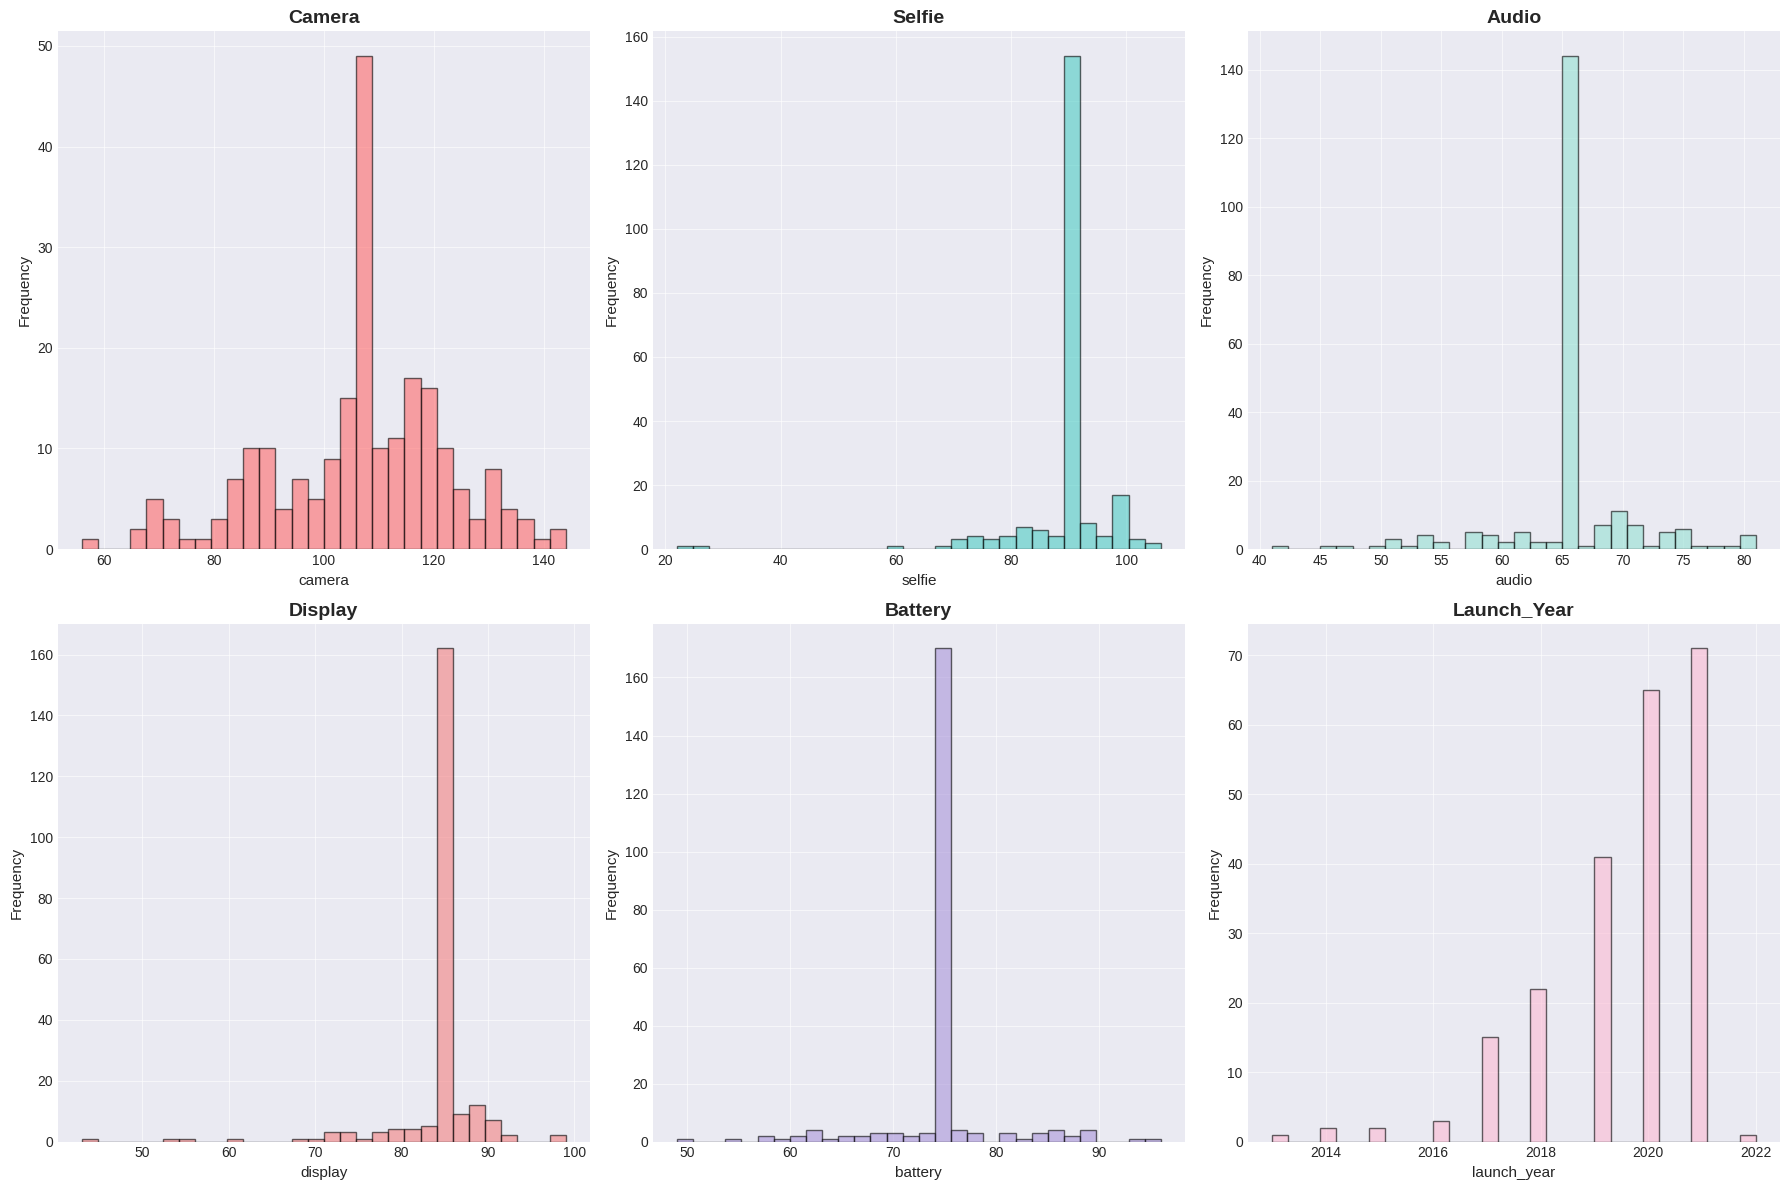

In [59]:
#visualisasi distribusi feature
fig, axes = plt.subplots(2, 3, figsize =(18,12))

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181', '#AA96DA', '#FCBAD3']
for idx, col in enumerate(feature_cols):
  row = idx //3
  col_idx = idx %3

  if idx <6:
    axes[row, col_idx].hist(df_clean[col].dropna(), bins=30,
                            edgecolor = 'black', alpha=0.6,
                            color = colors[idx])
    axes[row, col_idx].set_xlabel(col, fontsize = 11)
    axes[row, col_idx].set_ylabel('Frequency', fontsize=11)
    axes[row, col_idx].set_title(f'{col.title()}', fontsize =14, fontweight = 'bold')
    axes[row, col_idx].grid(alpha=0.6)

plt.tight_layout()
plt.show()

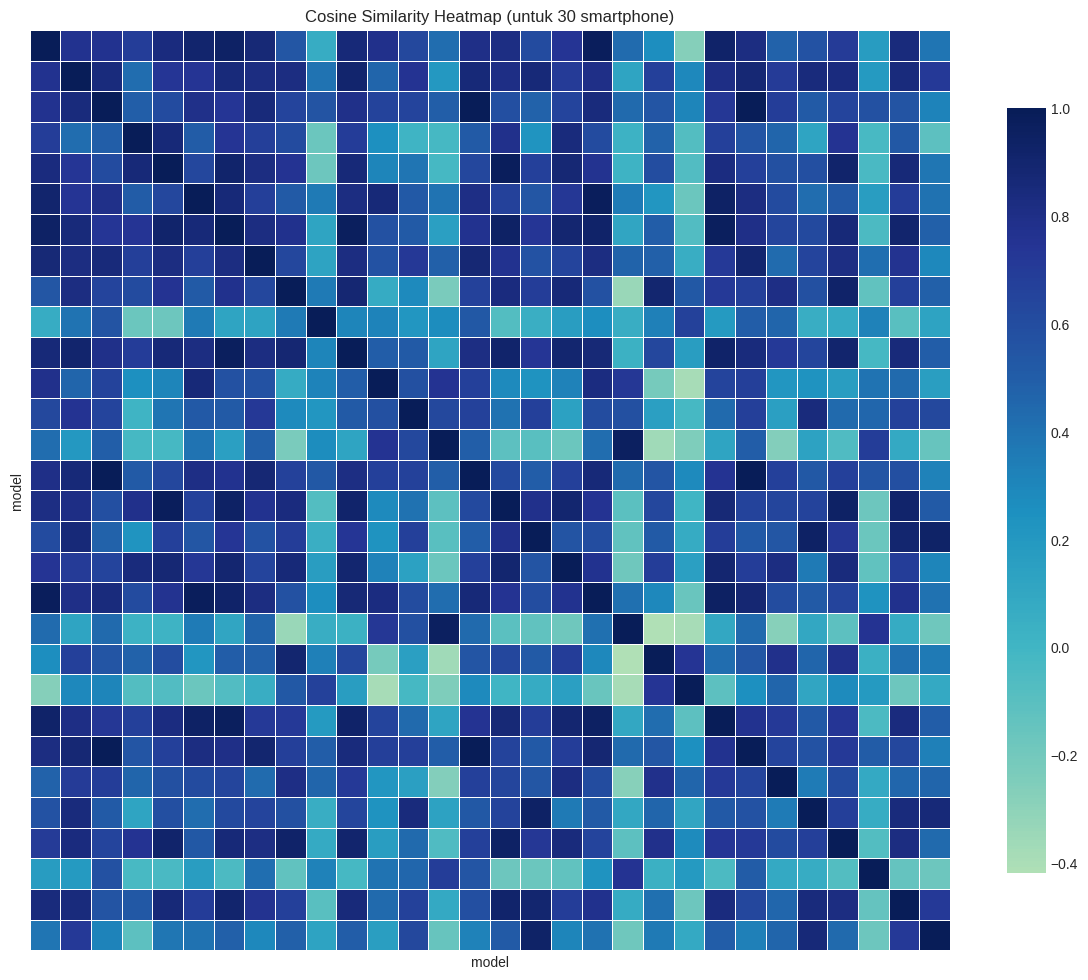

In [67]:
#heatmpa

plt.figure(figsize=(12,10))
sns.heatmap(
    cos_sim_df.iloc[:30,:30],
    cmap='YlGnBu',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    xticklabels=False,
    yticklabels=False
)

plt.title('Cosine Similarity Heatmap (untuk 30 smartphone)')
plt.tight_layout()
plt.show()

In [68]:
cos_sim_df

model,Huawei P50 Pro,Xiaomi Mi 11 Ultra,Huawei Mate 40 Pro+,Apple iPhone 13 Pro Max,Apple iPhone 13 Pro,Huawei Mate 40 Pro,Google Pixel 6 Pro,Vivo X70 Pro+,Asus Smartphone for Snapdragon Insiders,Xiaomi Mi 10 Ultra,Google Pixel 6,Huawei P40 Pro,Oppo Find X3 Pro,Vivo X70 Pro (MediaTek),Vivo X50 Pro+,Apple iPhone 13,Apple iPhone 13 mini,Apple iPhone 12 Pro Max,Apple iPhone 12 Pro,Vivo X60 Pro+,Xiaomi Mi 10 Pro,Oppo Find X2 Pro,Samsung Galaxy S20 Ultra 5G (Exynos),Honor 30 Pro+,Apple iPhone 11 Pro Max,OnePlus 9 Pro,Samsung Galaxy Z Fold3 5G,Huawei Mate 30 Pro 5G,Samsung Galaxy S21 Ultra 5G (Snapdragon),Apple iPhone 12 mini,Apple iPhone 12,Honor V30 Pro,Huawei Mate 30 Pro,Oppo Reno6 Pro 5G,Oppo Reno6 Pro+,Samsung Galaxy S21 Ultra 5G (Exynos),Xiaomi Mi CC9 Pro Premium Edition,Asus Zenfone 8,Google Pixel 5,Samsung Galaxy S21 FE 5G (Snapdragon),...,Altice S61,Huawei nova 6 5G,Samsung Galaxy S8,Meitu T9,Meitu V6,Intex Aqua Selfie,Black Shark 4S Pro,Honor Magic3 Pro +,Black Shark 4 Pro,Xiaomi Mi 10S,Asus ROG Phone 5,Asus ROG Phone 3,Lenovo Legion Phone 2 Pro,Xiaomi Redmi K40 Gaming,OnePlus 8,Nubia RedMagic 6 Pro,Nubia Red Magic 5S,Lenovo Legion Phone Pro,Realme GT 5G,Motorola Razr,Black Shark 3 Pro,Black Shark 2 Pro,Nubia Red Magic 3S,TCL 10 Pro,Microsoft Surface Duo,Fairphone 4,Realme C21,Samsung Galaxy M51,Xiaomi Redmi Note 10,Oppo A74,Wiko Power U30,Oppo A74 5G,Xiaomi Redmi Note 10 5G,Oppo A54 5G,Vivo Y20s,Huawei P40 Lite,Wiko Power U20,Motorola Moto G9 Power,Realme C11,Xiaomi Redmi 9
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Huawei P50 Pro,1.000000,0.771480,0.769063,0.685758,0.834911,0.911294,0.938773,0.869316,0.545242,0.066590,0.862313,0.779559,0.627872,0.427374,0.796066,0.813826,0.616811,0.745111,0.972532,0.432408,0.259382,-0.271497,0.921853,0.826923,0.482092,0.567082,0.705297,0.179328,0.848331,0.383087,0.670374,-0.120060,0.510109,0.421959,0.760215,0.508419,-0.094024,0.255214,0.023475,0.681305,...,-0.673352,0.531189,-0.538471,-0.556962,-0.574505,-0.571698,-0.146785,0.166809,-0.146785,0.176346,0.082867,-0.284576,-0.348957,0.439422,0.518614,-0.093964,0.562642,0.205658,0.172928,0.158797,-0.348184,0.025672,0.023329,0.202182,-0.312922,-0.274016,-0.358412,0.113262,0.184765,0.197951,0.197951,0.392802,0.392802,0.453234,0.729994,0.609961,0.358813,0.309382,0.110087,0.072240
Xiaomi Mi 11 Ultra,0.771480,1.000000,0.845618,0.419082,0.737101,0.740658,0.851219,0.820592,0.827116,0.394160,0.905959,0.468630,0.755637,0.200583,0.860107,0.801180,0.860588,0.706644,0.798770,0.122292,0.670145,0.295268,0.801411,0.874613,0.704559,0.849461,0.834734,0.190956,0.839777,0.714797,0.757089,-0.014470,0.212783,0.067399,0.809339,0.702349,-0.130368,0.656494,0.465297,0.726752,...,-0.825119,0.144318,-0.303957,-0.247186,-0.268713,-0.223328,0.264650,0.453078,0.264650,0.459403,0.425024,0.112701,-0.021258,0.523268,0.613704,-0.158941,0.196179,-0.158811,-0.063657,-0.198006,-0.234272,-0.329730,-0.329995,0.342659,-0.044649,-0.001178,0.014473,-0.257059,-0.147723,-0.130968,-0.130968,0.176412,0.176412,0.330367,0.480362,0.681248,0.564572,0.559806,0.431399,0.404026
Huawei Mate 40 Pro+,0.769063,0.845618,1.000000,0.490904,0.607343,0.792342,0.736799,0.853530,0.647445,0.555700,0.790074,0.661875,0.653316,0.491160,0.998383,0.589064,0.479659,0.652375,0.844487,0.436796,0.549241,0.306753,0.726776,0.991581,0.687007,0.516253,0.645994,0.578571,0.552021,0.314042,0.564826,0.335166,0.567661,0.421139,0.785213,0.303800,0.247008,0.377612,0.198956,0.522068,...,-0.970368,0.100068,-0.110251,-0.085792,-0.101511,-0.088235,0.027975,0.098907,0.027975,0.103688,0.089098,-0.012467,-0.034194,0.230617,0.274090,0.054749,0.276458,0.090792,0.096598,0.066749,-0.051249,-0.001778,-0.002947,0.245952,-0.008727,0.002012,-0.046448,0.060016,0.096963,0.103706,0.103706,0.202979,0.202979,0.233390,0.372999,0.309857,0.182816,0.155779,0.053929,0.034607
Apple iPhone 13 Pro Max,0.685758,0.419082,0.490904,1.000000,0.862731,0.512073,0.745227,0.680004,0.609002,-0.164246,0.699092,0.252236,

In [118]:
# pake TF-IDF buat filter brand
def setup_tfidf_vectorizer():
  tfidf = TfidfVectorizer(
      lowercase=True,
      max_features = 500,
      ngram_range=(1,2),
      stop_words='english',
      min_df=1
  )
  return tfidf

tfidf_vectorizer = setup_tfidf_vectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean['model'])
print(f"TF-IDF matrix : {tfidf_matrix.shape}")
print(f"  - Total phones: {tfidf_matrix.shape[0]}")
print(f"  - TF-IDF features: {tfidf_matrix.shape[1]}\n")


def extract_brand_group_tfidf(brand_keyword, top_n=None):
    # BRAND + ALIAS
    BRAND_ALIASES = {
    'apple': ['apple', 'iphone'],
    'samsung': ['samsung', 'galaxy'],
    'xiaomi': ['xiaomi', 'mi', 'redmi', 'poco', 'blackshark'],
    'oppo': ['oppo', 'find', 'reno'],
    'vivo': ['vivo', 'iqoo'],
    'realme': ['realme', 'narzo'],
    'oneplus': ['oneplus', 'nord'],
    'google': ['google', 'pixel'],
    'huawei': ['huawei', 'honor'],
    'asus': ['asus', 'rog', 'zenfone'],
    'sony': ['sony', 'xperia'],
    'nokia': ['nokia'],
    'motorola': ['motorola', 'moto'],
    'tecno': ['tecno', 'camon', 'phantom'],
    'infinix': ['infinix', 'zero', 'note', 'hot'],
    'itel': ['itel', 'vision'],
    'lenovo': ['lenovo', 'zuk'],
    'meizu': ['meizu'],
    'zte': ['zte', 'nubia', 'axon', 'blade'],
    'alcatel': ['alcatel', 'onetouch'],
    'lg': ['lg', 'wing', 'velvet'],
    'htc': ['htc', 'desire', 'u'],
    'tcl': ['tcl', 'alcatel'],
    'blackberry': ['blackberry'],
    'fairphone': ['fairphone'],
    'sharp': ['sharp', 'aquos'],
    'doogee': ['doogee', 'smini', 'n'],
    'umidigi': ['umidigi', 'a', 'bison'],
    'ulefone': ['ulefone', 'armor', 'note'],
    'oukitel': ['oukitel', 'wp', 'c', 'rt'],
    'bluboo': ['bluboo'],
    'cat': ['cat', 'caterpillar'],
    'energizer': ['energizer'],
    'blackview': ['blackview', 'bv'],
    'leeco': ['leeco', 'le', 'lephone'],
    'elephone': ['elephone'],
    'wiko': ['wiko', 'view', 'power'],
    'hisense': ['hisense'],
    'crosscall': ['crosscall'],
    'symphony': ['symphony'],
    'walton': ['walton', 'primo'],
    'maxwest': ['maxwest'],
    'blu': ['blu', 'bold'],
    'prestigio': ['prestigio', 'grace'],
    'plum': ['plum'],
    'verykool': ['verykool'],
    'acer': ['acer', 'liquid'],
    'toshiba': ['toshiba'],
    'philips': ['philips'],
    'benq': ['benq', 'siemens'],
    'haier': ['haier'],
    'palm': ['palm'],
    'sharp aquos': ['aquos'],
    'turing': ['turing'],
    'nextbit': ['nextbit', 'robin'],
    'shiftphone': ['shiftphone'],
    'roverphone': ['roverphone'],
    'gigaset': ['gigaset'],
    'emporia': ['emporia'],
    'yota': ['yota', 'yotaphone'],
    'bq': ['bq', 'aquaris'],
    'fly': ['fly'],
    'vodafone': ['vodafone', 'smart'],
    'vernee': ['vernee'],
    'innjoo': ['innjoo'],
    'advan': ['advan', 'g9', 'tab'],
    'evercoss': ['evercoss', 'a75a'],
    'polytron': ['polytron', 'zap'],
    'mito': ['mito'],
    'axioo': ['axioo'],
    'micromax': ['micromax', 'canvas', 'bharat'],
    'lava': ['lava', 'agni', 'z'],
    'karbonn': ['karbonn', 'titanium'],
    'spice': ['spice'],
    'xolo': ['xolo'],
    'celkon': ['celkon'],
    'iqoo': ['iqoo'],
    'poco': ['poco'],
    'nothing': ['nothing', 'phone'],
    'cubot': ['cubot', 'kingkong'],
    'blackshark': ['blackshark'],
    'doov': ['doov'],
    'smartron': ['smartron'],
    'turing': ['turing'],
    'prestigio': ['prestigio'],
    'yota': ['yota'],
    'shift': ['shift'],
    'sharp': ['sharp'],
    'energizer': ['energizer'],
    'casio': ['casio', 'gzone'],
    'panasonic': ['panasonic', 'eluga'],
    'toshiba': ['toshiba'],
    'philips': ['philips'],
    'haier': ['haier'],
    'benq': ['benq'],
    'acer': ['acer'],
    'nec': ['nec'],
    'kyocera': ['kyocera', 'digno'],
    'fujitsu': ['fujitsu', 'arrows']
}


    brand_keyword_lower = brand_keyword.lower()
    detected_brand = None

    # DETEKSI DARI ALIAS
    for brand, aliases in BRAND_ALIASES.items():
        for alias in aliases:
            if alias in brand_keyword_lower:
                detected_brand = brand
                break
        if detected_brand:
            break

    if detected_brand is None:
        detected_brand = brand_keyword_lower.split()[0]

    # STRING MATCHING PADA MODEL
    mask = df_clean['model'].str.lower().str.contains(detected_brand, na=False, regex=False)
    df_filtered = df_clean[mask].copy()

    if len(df_filtered) == 0:
        return pd.DataFrame()

    # TF-IDF FILTERED
    keyword_vector = tfidf_vectorizer.transform([detected_brand])
    tfidf_matrix_filtered = tfidf_vectorizer.transform(df_filtered['model'])
    sim = cosine_similarity(keyword_vector, tfidf_matrix_filtered).flatten()

    df_filtered['tfidf_score'] = sim
    brand_group = df_filtered[df_filtered['tfidf_score'] > 0].sort_values('tfidf_score', ascending=False)

    if top_n:
        brand_group = brand_group.head(top_n)

    return brand_group


# agregate statistik isi data (med, mean, mod)

def calculate_brand_statistics(brand_df, features=['camera', 'selfie', 'audio', 'display','battery']):
  stats_dict={}
  for feature in features:
    if feature in brand_df.columns:
      values =brand_df[feature].dropna()

      median_val = values.median()
      mean_val = values.mean()

      try:
        mode_val = stats.mode(values, keepdims=True).mode[0]
      except:
        mode_val = values.mode()[0] if len(values.mode())>0 else median_val

      stats_dict[feature] = {
          'median': median_val,
          'mean': mean_val,
          'mode': mode_val
      }
  return stats_dict


TF-IDF matrix : (223, 465)
  - Total phones: 223
  - TF-IDF features: 465



In [ ]:
# main functionnya SPR


#Brand Filttering
def get_brand_only(brand_keyword, stat_type='median', n_recomendations=10):
  try:
    exact_match = None

    if brand_keyword in df_clean['model'].values:
      exact_match = brand_keyword
      print(f"[EXACT MATCH] ditemukan : '{exact_match}'")
    else:
      matches = df_clean[df_clean['model'].str.lower()==brand_keyword.lower()]
      if len(matches)>0:
        exact_match = matches.iloc[0]['model']
      else:
        matches = df_clean[df_clean['model'].str.lower().str.contains(brand_keyword.lower(), na=False, regex=False)]
        if len(matches)==1:
          exact_match = matches.iloc[0]['model']
        else:
          print(f"tidak ada yang matches dengan brand keyword")


    brand_group = extract_brand_group_tfidf(brand_keyword)

    if len(brand_group)==0:
      return f"tidak ditemukan ponsel dengan keyword merk : {brand_keyword}"


    ref_profile = []
    ref_profile_dict = {}
    profile_source = ""

    if exact_match:
      #pake real spec
      phone_data = df_clean[df_clean['model']==exact_match].iloc[0]

      for feature in feature_cols:
        if feature == 'launch_year':
          value = phone_data.get('launch_year', 'N/A')
        else:
          value = phone_data.get(feature, 'N/A')
        ref_profile.append(value)
        ref_profile_dict[feature] = value
      profile_source = f"Real Data :{exact_match}"
    else:
      #mode virtual profile

      brand_stats = calculate_brand_statistics(brand_group, feature_cols[:-1] if'launch_year' in feature_cols else feature_cols)


      for feature in feature_cols:
        if feature == 'launch_year':
          value = brand_group['launch_year'].median()
        else:
          value = brand_stats[feature][stat_type]


        ref_profile.append(value)
        ref_profile_dict[feature]=value
      profile_source = f"VIRTUAL PROFILE ({stat_type.upper()})"


    #normalize feature virtual
    reference_profile_scaled = scaler.transform([ref_profile])

    #hitung cosine sim hanya untuk ponsel dalam brand grop

    #ambil index brand_group
    brand_indices = brand_group.index

    #ambil feature yang telah di scaling
    brand_features_scaled = df_features_scaled.loc[brand_indices]

    #hitung similarity
    sim = cosine_similarity(reference_profile_scaled, brand_features_scaled).flatten()

    #buat dataframe hasil dari brand filtering
    result_df = brand_group.copy()
    result_df['similarity'] = sim

    if exact_match:
      result_df = result_df[result_df['model']!=exact_match]
      print(f"  Excluded exact match '{exact_match}' from recommendations")

    top_recomendations = result_df.nlargest(n_recomendations, 'similarity')


    #format output
    brand_name = brand_keyword.split()[0].upper()
    result_text = f"# Rekomendasi Ponsel - {brand_name}\n\n"

      # Header berdasarkan mode
    if exact_match:
        result_text += f"**Mode:** SPECIFIC PHONE (Real Specs)\n"
        result_text += f"**Reference Phone:** {exact_match}\n"
    else:
        result_text += f"**Mode:** BRAND STATISTICS\n"
        result_text += f"**Metode:** TF-IDF Filtering + Statistical Aggregation ({stat_type.upper()})\n"

    result_text += f"**Total ponsel di grup:** {len(brand_group)}\n"
    result_text += f"**Menampilkan:** Top {min(n_recomendations, len(top_recomendations))} rekomendasi\n\n"

    # Reference profile section
    result_text += f"## Reference Profile ({profile_source}):\n"


    for feature, value in ref_profile_dict.items():
      result_text += f"**{feature.replace('_', ' ').title()}:** {value:.2f}\n"

    result_text += f"\n## Top{min(n_recomendations, len(top_recomendations))} Rekomendasi Serupa : "

    recomendations = []
    for i, (idx, row) in enumerate(top_recomendations.iterrows(),1):
      sim = row['similarity']
      result_text += f"### {i}. **{row['model']}**\n"
      result_text += f"   -  Similarity: **{row['similarity']:.4f}** ({sim:.1f}%)\n"
      result_text += f"   -  Camera: {row['camera']:.1f} |  Display: {row['display']:.1f} |  Battery: {row['battery']:.1f}\n"
      result_text += f"   -  Selfie: {row['selfie']:.1f} |  Audio: {row['audio']:.1f}\n\n"

      recomendations.append({
                'Rank': i,
                'Model': row['model'],
                'Similarity': f"{row['similarity']:.4f}",
                'Similarity %': f"{sim:.1f}%",
                'Camera': f"{row['camera']:.1f}",
                'Display': f"{row['display']:.1f}",
                'Battery': f"{row['battery']:.1f}",
                'Audio': f"{row['audio']:.1f}",
                'Selfie': f"{row['selfie']:.1f}"
            })

    result_df_final = pd.DataFrame(recomendations)

    return result_text, result_df
  except Exception as e:
    import traceback
    error_detail = traceback.format_exc()
    print(f"\n{'='*70}")
    print(f"❌ [ERROR] {str(e)}")
    print(f"{'='*70}")
    print(error_detail)
    return f"❌ Error: {str(e)}\n\nDetail:\n{error_detail}", None


#ambil HP original
def get_sim_phone_content_based(phone_model, n_recomendations=10):
  try:
    if phone_model not in cos_sim_df.index:
      matches = [p for p in cos_sim_df.index if phone_model.lower() in p.lower()]
      if matches:
        phone_model=matches[0]
      else:
        return f" merk {phone_model} tidak ditemukan", None,None

    sim_scores = cos_sim_df[phone_model].sort_values(ascending=False)
    sim_phone = sim_scores.iloc[1:n_recomendations+1]

    recomendations = []
    for phone, score in sim_phone.items():
      phone_data = df_clean[df_clean['model']==phone].iloc[0]
      recomendations.append({
          'Model': phone,
          'Similarity': f"{score:.4f}",
          'Camera': phone_data.get('camera', 'N/A'),
          'Display': phone_data.get('display', 'N/A'),
          'Audio': phone_data.get('audio', 'N/A'),
          'Battery': phone_data.get('battery', 'N/A')
      })
    result_df = pd.DataFrame(recomendations)
    result_text = f"# Similar phones to **{phone_model}**\n\nTop {n_recomendations} results based on cosine similarity."

    return result_text, result_df, None
  except Exception as e:
    return f"Error : {str(e)}", None, None


def search_phone(query, max_results =20):
  try:
    matches = [phone for phone in df_clean['model'] if query.lower() in phone.lower()]
    if not matches:
      return f"Tidak ditemukan ponsel yang cocok dengan kata kunci '{query}'"
    results = []
    for phone in matches[:max_results]:
      phone_data = df_clean[df_clean['model']==phone].iloc[0]
      results.append({
          'Model': phone,
          'Camera': phone_data.get('camera', 'N/A'),
          'Display': phone_data.get('display', 'N/A'),
          'Audio': phone_data.get('audio', 'N/A'),
          'Battery': phone_data.get('battery', 'N/A')
      })
    result_df = pd.DataFrame(results)
    result_text = f"# Hasil Pencarian: '{query}'\nDitemukan {len(matches)} ponsel"

    return result_text, result_df
  except Exception as e:
    return f"Error: {str(e)}", None

In [120]:
# UI pake Gradio

def create_advanced_phone_finder():
    """Create advanced Gradio app with TF-IDF and statistical features"""

    custom_css = """
    .gradio-container {
        font-family: 'Segoe UI', sans-serif;
        max-width: 1400px;
    }
    .gr-button-primary {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
        border: none !important;
    }
    """

    with gr.Blocks(css=custom_css, title="Advanced Phone Finder", theme=gr.themes.Soft()) as app:

        gr.Markdown("""
        # Advanced Phone Recommendation System
        ### Dengan TF-IDF Brand Filtering & Statistical Aggregation
        **Author:** rasiharunart1 | **Updated:** 2025-10-30

        ---
        """)

        # KEMAMPUAN 6: TAB UTAMA - Brand-Based Recommendations
        with gr.Tab("Brand-Based Recommendations"):
            gr.Markdown("""
            ### Rekomendasi Berdasarkan Brand Group Statistics
            **Cara Kerja:**
            1. Input brand keyword (e.g., 'apple', 'samsung', 'xiaomi')
            2. Sistem ekstrak grup ponsel dengan TF-IDF
            3. Hitung median/mean/mode dari spesifikasi grup
            4. Generate rekomendasi ponsel dari brand yang sama
            """)

            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("#### Configuration")

                    # INPUT CAPABILITY 1: Brand keyword input
                    brand_input = gr.Textbox(
                        label="Brand Keyword",
                        placeholder="e.g., apple, samsung, xiaomi, oppo",
                        info="Masukkan nama brand untuk filtering",
                        lines=1
                    )

                    # INPUT CAPABILITY 3: Statistical method selection
                    stat_method = gr.Radio(
                        choices=['median', 'mean', 'mode'],
                        value='median',
                        label="Metode Statistik",
                        info="Pilih metode agregasi untuk profil virtual"
                    )

                    # INPUT CAPABILITY 6: Number input (bukan slider)
                    n_recs_brand = gr.Number(
                        label="Jumlah Rekomendasi",
                        value=10,
                        minimum=1,
                        maximum=50,
                        step=1,
                        info="Masukkan jumlah hasil rekomendasi"
                    )

                    find_brand_btn = gr.Button("Generate Recommendations", variant="primary", size="lg")

                with gr.Column(scale=2):
                    gr.Markdown("#### Hasil Rekomendasi")
                    brand_output = gr.Markdown()
                    brand_table = gr.Dataframe(wrap=True)

            # brand_chart = gr.Plot(label="Feature Comparison Chart")

            # Connect function
            find_brand_btn.click(
                fn=get_brand_only,
                inputs=[brand_input, stat_method, n_recs_brand],
                outputs=[brand_output, brand_table]
            )

            # Example buttons
            gr.Markdown("#### Coba contoh brand:")
            with gr.Row():
                ex_apple = gr.Button("Apple", size="sm")
                ex_samsung = gr.Button("Samsung", size="sm")
                ex_xiaomi = gr.Button("Xiaomi", size="sm")
                ex_oppo = gr.Button("Oppo", size="sm")

            ex_apple.click(lambda: "apple", outputs=[brand_input])
            ex_samsung.click(lambda: "samsung", outputs=[brand_input])
            ex_xiaomi.click(lambda: "xiaomi", outputs=[brand_input])
            ex_oppo.click(lambda: "oppo", outputs=[brand_input])

        # TAB 2: Original similarity search
        with gr.Tab("Find Similar Phones (Original)"):
            gr.Markdown("### Cari ponsel serupa berdasarkan model spesifik")

            with gr.Row():
                with gr.Column(scale=1):
                    phone_input = gr.Textbox(
                        label="Phone Model",
                        placeholder="e.g., iPhone 14 Pro",
                        lines=1
                    )

                    n_similar = gr.Number(
                        label="Jumlah Rekomendasi",
                        value=10,
                        minimum=1,
                        maximum=50,
                        step=1
                    )

                    find_btn = gr.Button("Find Similar", variant="primary")

                with gr.Column(scale=2):
                    similar_output = gr.Markdown()
                    similar_table = gr.Dataframe()

            similar_chart = gr.Plot()

            find_btn.click(
                get_sim_phone_content_based,
                [phone_input, n_similar],
                [similar_output, similar_table, similar_chart]
            )

        # TAB 3: Search
        with gr.Tab("Search Phones"):
            gr.Markdown("### Cari ponsel berdasarkan nama atau brand")

            with gr.Row():
                search_input = gr.Textbox(label="Search Query", placeholder="e.g., iPhone, Galaxy")
                search_btn = gr.Button("Search", variant="primary")

            search_output = gr.Markdown()
            search_table = gr.Dataframe()

            search_btn.click(search_phone, [search_input], [search_output, search_table])

        # TAB 4: About
        with gr.Tab("About"):
            gr.Markdown(f"""
            ## Dataset Information

            - **Total Phones:** {len(df_clean):,}
            - **Features:** {len(feature_cols)}
            - **TF-IDF Vocabulary:** {tfidf_matrix.shape[1]} terms

            ## New Features

            ### 1. TF-IDF Brand Filtering
            - Menggunakan TF-IDF vectorization untuk matching brand
            - Lebih akurat daripada simple string matching
            - Dapat menangani variasi nama (e.g., "Apple" vs "apple iphone")

            ### 2. Statistical Aggregation
            - **Median**: Nilai tengah (robust terhadap outlier)
            - **Mean**: Rata-rata (representasi umum)
            - **Mode**: Nilai paling sering muncul

            ### 3. Virtual Profile Generation
            - Sistem membuat profil ponsel virtual dari statistik grup
            - Mencari ponsel real yang paling mirip dengan profil virtual
            - Rekomendasi HANYA dari brand yang diminta

            ### 4. Dynamic Recommendation Control
            - Input form untuk mengatur jumlah rekomendasi
            - Kontrol ada di semua mode rekomendasi

            ## Algoritma

            1. **TF-IDF Filtering**: Text vectorization untuk brand matching
            2. **Statistical Aggregation**: Median/Mean/Mode calculation
            3. **Cosine Similarity**: Pengukuran kemiripan fitur
            4. **StandardScaler**: Normalisasi fitur

            ## Developer

            **Author:** rasiharunart1
            **Date:** 2025-10-30
            **Version:** 2.0 (Refactored)

            ---

            <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 20px; border-radius: 10px; text-align: center;">
                <h3>6 Input Capabilities Implemented</h3>
                <p>TF-IDF | Statistical Aggregation | Dynamic Control</p>
            </div>
            """)

        gr.Markdown("""
        ---
        <div style="text-align: center; color: #666;">
            <p>Advanced Phone Recommendation System | rasiharunart1 2025</p>
        </div>
        """)

    return app

print("Gradio app created with advanced features!\n")

Gradio app created with advanced features!



In [ ]:
# Launch App

app = create_advanced_phone_finder()
app.launch(share=True, debug=True, inbrowser=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1b0e4af4f8f974a05f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


tidak ada yang matches dengan brand keyword
tidak ada yang matches dengan brand keyword
